In [1]:
!pip install --upgrade numba -q

In [2]:
!pip install --upgrade numpy -q

In [3]:
!pip install --upgrade matplotlib -q


Usage:   
  pip <command> [options]

no such option: --upgrade


In [4]:
!pip install seaborn==0.13.2 -q

In [5]:
!pip install phik -q

In [6]:
!pip install shap -q

In [7]:
!pip install scikit-learn==1.6.1 -q

In [8]:
!pip install --upgrade pandas -q

# Описание проекта

Для интернет-магазина "В один клик", в связи со снижением активности покупателей, необходимо разработать решение, позволяющее персонализировать предложения постоянным клиентам для увеличения их покупательской активности:
- промаркировать уровень финансовой активности постоянных покупателей (активность снизилась или осталась на прежнем уровне;
- собрать данные клиетов по группам :
  * признаки, описывающие коммуникацию сотрудников компании с клиентом;
  * признаки, описывающие продуктовое поведение;
  * признаки, описывающие покупательское поведение;
  *  признаки, описывающие поведение покупателя на сайте.
- разработать модель, предсказывающую вероятность снижения покупательской активности клиента в следующие три месяца.
- включить в исследование данные финансового департамента (доход покупателяза последние три месца)
- На основании предсказаний модели и данных о прибыльности клиентов необходимо выделить сегменты покупателей и разработать для них пресонализированные предложения.


Работа над проектом будет выполняться в несколько этапов:
1. предобработка данных;
2. иследовательский анализ данных;
3. Объединение данных из нескольких таблиц
4. корреляционный анализ данных, с целью изучения взаимосвязей между разными признаками;
5. создание пайплайнов;
6. анализ важности признаков;
7. сегментация покупателей

**Описание данных**
1. таблица market_file.csv:
- id — номер покупателя в корпоративной базе данных.
- Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
- Тип сервиса — уровень сервиса, например «премиум» и «стандарт».
- Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
- Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
- Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.
- Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
- Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
- Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.
- Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
- Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.
- Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.
- Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

2. таблица market_money.csv:
- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксирована выручка. Например,
'текущий_месяц' или 'предыдущий_месяц'.
- Выручка — сумма выручки за период.

3. таблица market_time.csv:
- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксировано общее время.
- минут — значение времени, проведённого на сайте, в минутах.

4. таблица money.csv:
- id — номер покупателя в корпоративной базе данных.
- Прибыль — значение прибыли.


## Шаг 1. Загрузка данных

In [9]:
# шаг 1 
import pandas as pd
import sklearn

# шаг 3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# шаг 5
import phik
from phik.report import plot_correlation_matrix

# шаг 6
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, 
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV,\
    GridSearchCV
from sklearn.metrics import roc_auc_score

# шаг 7
import shap
import time

In [10]:
# Инициализация константы
RANDOM_STATE = 42

In [11]:
try:
    market_file = pd.read_csv(r'C:\Users\Dmitriy\Desktop\курсы\module_2\12. обучение с учителем\project\market_file.csv')
    market_money = pd.read_csv(r'C:\Users\Dmitriy\Desktop\курсы\module_2\12. обучение с учителем\project\market_money.csv')
    market_time = pd.read_csv(r'C:\Users\Dmitriy\Desktop\курсы\module_2\12. обучение с учителем\project\market_time.csv')
    money = pd.read_csv(r'C:\Users\Dmitriy\Desktop\курсы\module_2\12. обучение с учителем\project\money.csv', sep=';')
except:
    market_file = pd.read_csv('/datasets/market_file.csv')
    market_money = pd.read_csv('/datasets/market_money.csv')
    market_time = pd.read_csv('/datasets/market_time.csv')
    money = pd.read_csv('/datasets/money.csv', sep=';')

In [12]:
market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [13]:
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [14]:
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [15]:
money.head()

,id,Прибыль
0,215348,"0,98"
1,215349,"4,16"
2,215350,"3,13"
3,215351,"4,87"
4,215352,"4,21"


In [16]:
# переименование столбцов таблицы market_file
market_file = market_file.rename(columns={
    'Покупательская активность' : 'покупательская_активность',
    'Тип сервиса' : 'тип_сервиса',
    'Разрешить сообщать': 'разрешить_сообщать'
})

In [17]:
# вывод общей информации о датафрейме market_file
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [18]:
# вывод общей информации о датафрейме market_money
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [19]:
# вывод общей информации о датафрейме market_time
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [20]:
# вывод общей информации о датафрейме money
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1300 non-null   int64 
 1   Прибыль  1300 non-null   object
dtypes: int64(1), object(1)
memory usage: 20.4+ KB


### Вывод

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

На этапе изучения общей информации, в данных не обнаружено пропусков, возможно, присутствуют некорректные значения, а также дубликаты (будут выявлены на этапе предобработки и исследовательского анализа данных).\
У столбца Прибыль таблицы money некорректный тип данных (будет исправлено на этапе предобработки данных)

## Шаг 2. Предобработка данных

На данном этапе будет проведена работа по: 
- изменению некорректного типа данных;
- выявлению дубликатов.

### Изменение типа данных столбца Прибыль таблицы money на float

In [21]:
# перед изменениние типа данных заменим разделители запятые на точки
money['Прибыль'] = money['Прибыль'].str.replace(',', '.')

# изменение типа данных таблицы money
money['Прибыль'] = money['Прибыль'].astype(float)

In [22]:
# вывод общей информации о датафрейме после преобразования
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


### Обработка дубликатов

перед обработкой дубликатов приведем строковые значения к нижнему регистру

In [23]:
# функция перевода названий столбцов и строковых значений датафрейма в нижний регистр
def to_lowercase(df):
    # приведение названий столбцов к нижнему регистру
    df.columns = df.columns.str.lower()
    
    # приведение строковых значений к нижнему регистру
    try:
        df = df.map(lambda x: x.lower() if isinstance(x, str) else x)
    except:
#        df = df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
        pass
    return df

In [24]:
# приведение данных датафреймов к нижнему регистру
market_file = to_lowercase(market_file)
market_money = to_lowercase(market_money)
market_time = to_lowercase(market_time)
money = to_lowercase(money)

In [25]:
# подсчет количества строк дубликатов в датафреймах
print(
    f"количество строк дубликатов таблицы market_file: {market_file.duplicated().sum()}",
    f"количество строк дубликатов таблицы market_money: {market_money.duplicated().sum()}",
    f"количество строк дубликатов таблицы market_time: {market_time.duplicated().sum()}",
    f"количество строк дубликатов таблицы money: {money.duplicated().sum()}",
    sep='\n'
)

количество строк дубликатов таблицы market_file: 0
количество строк дубликатов таблицы market_money: 0
количество строк дубликатов таблицы market_time: 0
количество строк дубликатов таблицы money: 0


\
Т.к. явных дубликатов не выявлено выполним поиск неявных

In [26]:
# столбцы с типом данных object из всех представленных таблиц
all_cat_col = ['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
               'популярная_категория', 'период']

In [27]:
# неявные дубликаты таблицы market_file
for col in all_cat_col:
    if col in market_file.columns:
        print(f"уникальные значения столбца {col}: {market_file[col].unique()}")

уникальные значения столбца покупательская_активность: ['снизилась' 'прежний уровень']
уникальные значения столбца тип_сервиса: ['премиум' 'стандартт' 'стандарт']
уникальные значения столбца разрешить_сообщать: ['да' 'нет']
уникальные значения столбца популярная_категория: ['товары для детей' 'домашний текстиль' 'косметика и аксесуары'
 'техника для красоты и здоровья' 'кухонная посуда'
 'мелкая бытовая техника и электроника']


In [28]:
# удаление неявных дубликатов таблицы market_file
market_file['тип_сервиса'] = market_file['тип_сервиса'].str.replace('стандартт', 'стандарт')

In [29]:
# исправление значения в столбце популярная_категория таблицы market_file
market_file['популярная_категория'] =\
    market_file['популярная_категория'].str.replace('косметика и аксесуары', 'косметика и аксессуары')

In [30]:
# проверка таблицы market_file после удаления неявных дубликатов
for col in all_cat_col:
    if col in market_file.columns:
        print(f"уникальные значения столбца {col}: {market_file[col].unique()}")

уникальные значения столбца покупательская_активность: ['снизилась' 'прежний уровень']
уникальные значения столбца тип_сервиса: ['премиум' 'стандарт']
уникальные значения столбца разрешить_сообщать: ['да' 'нет']
уникальные значения столбца популярная_категория: ['товары для детей' 'домашний текстиль' 'косметика и аксессуары'
 'техника для красоты и здоровья' 'кухонная посуда'
 'мелкая бытовая техника и электроника']


In [31]:
# неявные дубликаты таблицы market_money
for col in all_cat_col:
    if col in market_money.columns:
        print(f"уникальные значения столбца {col}: {market_money[col].unique()}")

уникальные значения столбца период: ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


In [32]:
# неявные дубликаты таблицы market_time
for col in all_cat_col:
    if col in market_time.columns:
        print(f"уникальные значения столбца {col}: {market_time[col].unique()}")

уникальные значения столбца период: ['текущий_месяц' 'предыдцщий_месяц']


In [33]:
# исправление значения в столбце период таблицы market_time
market_time['период'] = market_time['период'].str.replace('предыдцщий_месяц', 'предыдущий_месяц')

In [34]:
# проверка таблицы market_time после исправления значения
for col in all_cat_col:
    if col in market_time.columns:
        print(f"уникальные значения столбца {col}: {market_time[col].unique()}")

уникальные значения столбца период: ['текущий_месяц' 'предыдущий_месяц']


### Вывод

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

В результате предварительной обработки данных:
- строковые значения датафреймов приведены к нижнему регистру;
- изменен тип данных с `object` на `float` в столбце `Прибыль` таблицы money;
- удалены неявные дубликаты из таблицы market_file;
- исправлено значение в столбце период таблицы market_time;
- исправлено значение в столбце популярная_категория таблицы market_file.

## Шаг 3. Исследовательский анализ данных

В данном разделе:
1. будет проведен статистический анализ количественных признаков датафреймов;
2. Построены графики для визуализации распределения данных датафреймов;
3. из таблицы market_money будут отобраны клиенты, совершавшие покупки в течение трех месяцев.

### Статистический анализ

In [35]:
# сводная статистика количественных столбцов таблицы market_file
market_file.drop(columns='id').describe()

,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [36]:
# сводная статистика количественных столбцов таблицы market_money
market_money.drop(columns='id').describe()

,выручка
count,3900.000000
mean,5025.696051
std,1777.704104
min,0.000000
25%,4590.150000
50%,4957.500000
75%,5363.000000
max,106862.200000


Максимальное значение выручки таблицы market_money сильно выделяется среди остальных, скорее всего, оно ошибочно.\
Удалим строки со значением выручки более 100000

In [37]:
market_money = market_money.query('выручка <= 100000').reset_index(drop=True)

In [38]:
# проверка сводной статистики количественных столбцов таблицы market_money
market_money.drop(columns='id').describe()

,выручка
count,3899.00000
mean,4999.57743
std,706.99988
min,0.00000
25%,4590.10000
50%,4957.00000
75%,5363.00000
max,7799.40000


In [39]:
# сводная статистика количественных столбцов таблицы market_time
market_time.drop(columns='id').describe()

,минут
count,2600.000000
mean,13.336154
std,4.080198
min,4.000000
25%,10.000000
50%,13.000000
75%,16.000000
max,23.000000


In [40]:
# сводная статистика количественных столбцов таблицы money
money.drop(columns='id').describe()

,прибыль
count,1300.000000
mean,3.996631
std,1.013722
min,0.860000
25%,3.300000
50%,4.045000
75%,4.670000
max,7.430000


### Построение графиков

перед визуализацией признаков напишем функцию в целях сокращения кода

In [41]:
def visualization(df, column, x_label, num_col=True):
    '''
    функция визуализации количественных или категориальных столбцов
    df - датафрейм
    column - столбец для данных которого строится график
    x_label - подпись оси х
    num_col - количественные данные
    если num_col=False, то стоятся графики для категориальных данных
    '''
    # для количественных столбцов
    if num_col:
        # гистрограмма
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 7))
        sns.histplot(data=df, bins=20,
                     x=column,
                     ax=ax1)

         # добавление линии среднего
        ax1.axvline(np.mean(df[column]), linestyle='--', 
                    linewidth=1.5, color='r',
                    label=f'среднее значение: {np.mean(df[column]):.2f}',
                    fillstyle='left')    

        # настройка графика гистограммы
        ax1.grid(alpha=0.5)
        ax1.legend(loc='upper left')
        ax1.set_xlabel(x_label)
        ax1.set_ylabel('количество пользователей')

        # диаграмма размаха
        df.boxplot(ax=ax2,
                   column=column,
                   patch_artist=True,
                   vert=False,
                  boxprops=dict(facecolor='cornflowerblue'))

        # настройка графика диаграммы размаха
        plt.suptitle(f'Гистограмма и диаграмма размаха для столбца: {column}')
        ax2.set_xlabel(x_label)
        
        plt.show()

    # для категориальных столбцов
    else:
        # построение столбчатой диаграммы распределения количества
        ax = df.groupby(column)[column].count().plot(kind='bar',
                                                xlabel=x_label, 
                                                ylabel='количество пользователей',
                                                figsize=(8, 5),
                                                width=0.5)

        # настройка графика
        ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
        ax.set_title(f'распределение количества сгруппированных данных для столбца: {column}')
        for _i in ax.patches:
            ax.annotate(str(_i.get_height()),
                        (_i.get_x() + _i.get_width() / 2,
                         _i.get_height()),
                        ha='center',
                        va='center',
                        xytext=(0, 5),
                       textcoords='offset points')

#### Графикидля таблицы market_file

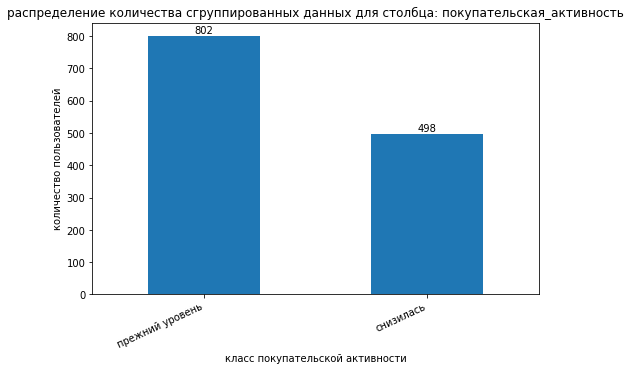

In [42]:
visualization(market_file, 'покупательская_активность', 'класс покупательской активности', num_col=False)

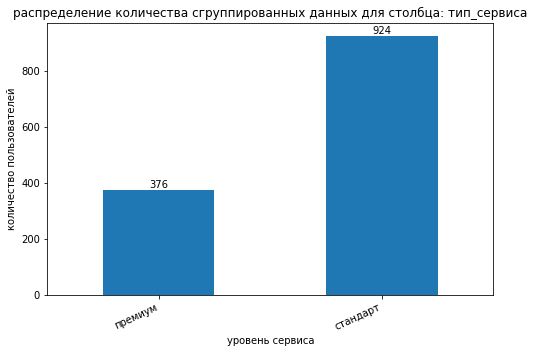

In [43]:
visualization(market_file, 'тип_сервиса', 'уровень сервиса', num_col=False)

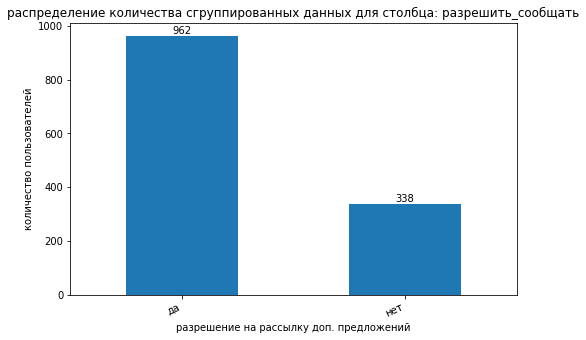

In [44]:
visualization(market_file, 'разрешить_сообщать', 'разрешение на рассылку доп. предложений', num_col=False)

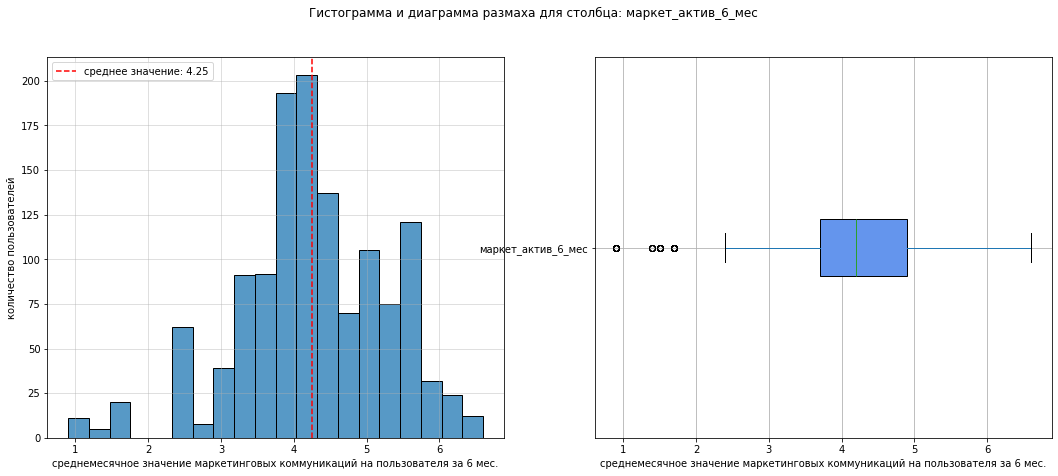

In [45]:
visualization(market_file,
              'маркет_актив_6_мес',
              'среднемесячное значение маркетинговых коммуникаций на пользователя за 6 мес.',
              num_col=True)

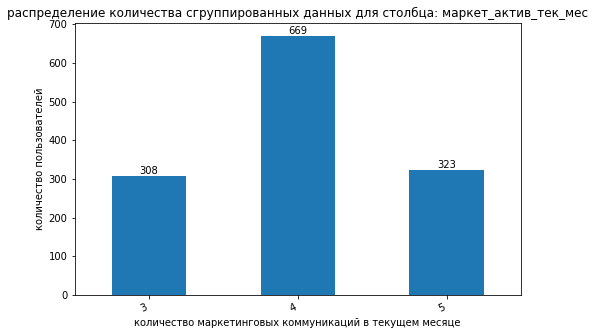

In [46]:
visualization(market_file,
              'маркет_актив_тек_мес',
              'количество маркетинговых коммуникаций в текущем месяце',
              num_col=False)

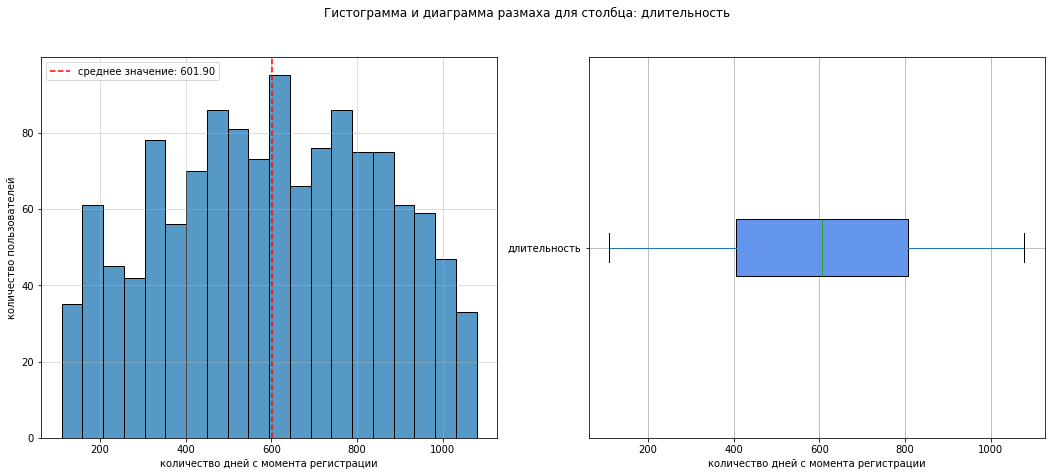

In [47]:
visualization(market_file,
              'длительность',
              'количество дней с момента регистрации',
              num_col=True)

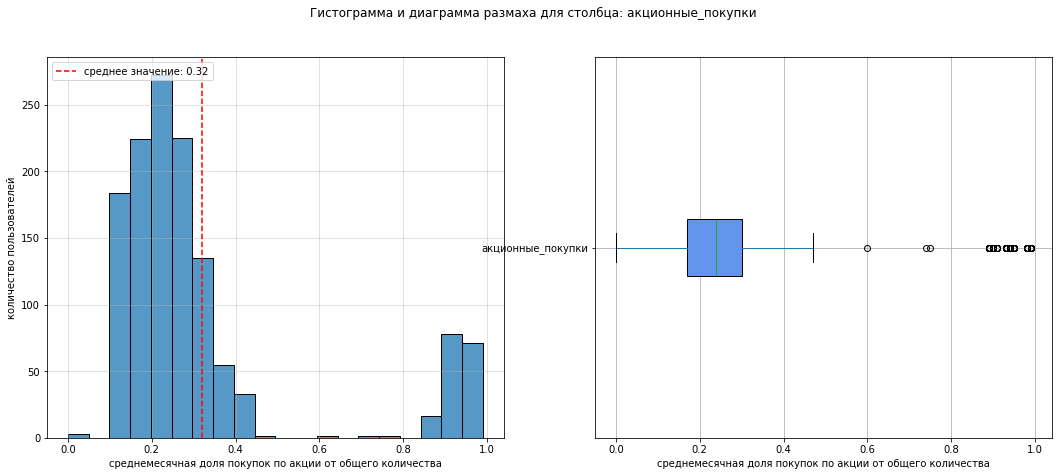

In [48]:
visualization(market_file,
              'акционные_покупки',
              'среднемесячная доля покупок по акции от общего количества',
              num_col=True)

\
Переведем количественный признак акционные_покупки в категориальный

In [49]:
# перевод згачений столбца акционные_покупки в категориальный бинарный признак
market_file['акционные_покупки'] = market_file['акционные_покупки'].apply(
    lambda x: 'маленькая_доля' if x < 0.5 else 'большая_доля')

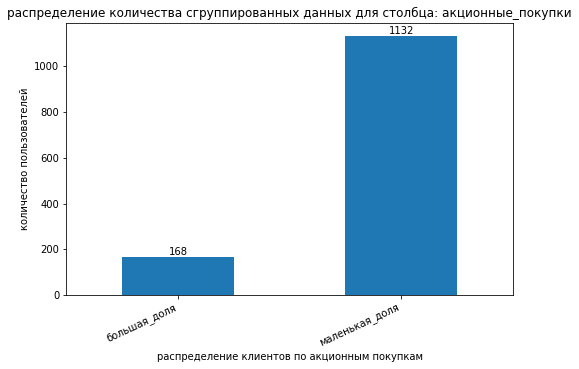

In [50]:
# визуализация данных столбца акционные_покупки
# как категориный признак
visualization(market_file,
              'акционные_покупки',
              'распределение клиентов по акционным покупкам',
              num_col=False)

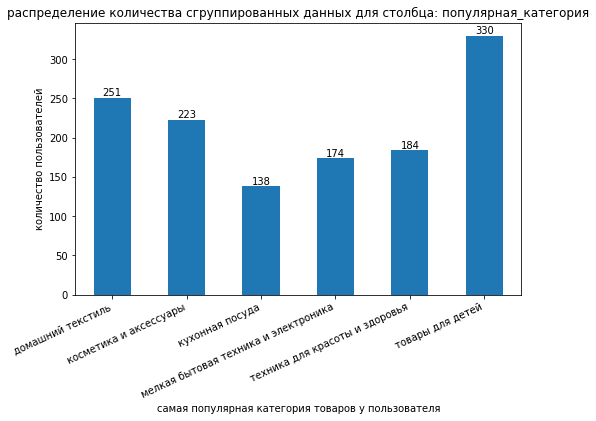

In [51]:
visualization(market_file,
              'популярная_категория',
              'самая популярная категория товаров у пользователя',
              num_col=False)

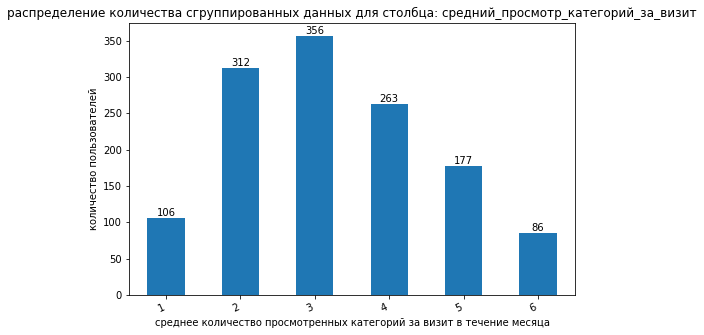

In [52]:
visualization(market_file,
              'средний_просмотр_категорий_за_визит',
              'среднее количество просмотренных категорий за визит в течение месяца',
              num_col=False)

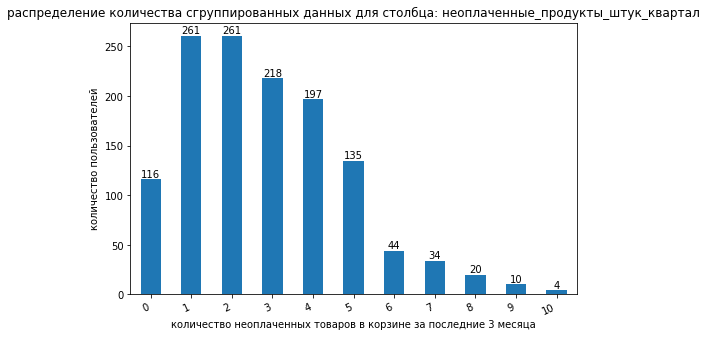

In [53]:
visualization(market_file,
              'неоплаченные_продукты_штук_квартал',
              'количество неоплаченных товаров в корзине за последние 3 месяца',
              num_col=False)

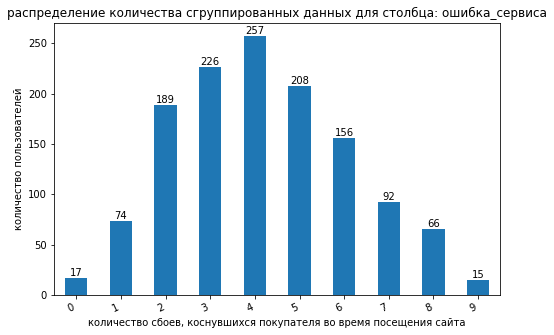

In [54]:
visualization(market_file,
              'ошибка_сервиса',
              'количество сбоев, коснувшихся покупателя во время посещения сайта',
              num_col=False)

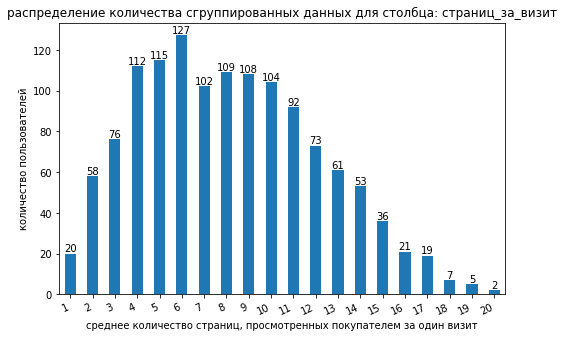

In [55]:
visualization(market_file,
              'страниц_за_визит',
              'среднее количество страниц, просмотренных покупателем за один визит',
              num_col=False)

#### Графики для таблицы market_money

Перед визуализацией данных отберем пользователей, которые совершали покупки в каждый период в представленных данных

In [56]:
# сводная таблица с id пользователей и соответствующей выручкой по периодам
users_by_period = market_money.pivot_table(index='id', columns='период', values='выручка')

In [57]:
# получение id пользователей,
# у которых покупательская активность зафиксирована в каждом периоде
users_ids = users_by_period[
    (users_by_period['препредыдущий_месяц'] > 0) &
    (users_by_period['предыдущий_месяц'] > 0) &
    (users_by_period['текущий_месяц'] > 0)
].index

# обновление данных таблицы market_money
market_money = market_money[market_money['id'].isin(users_ids)]

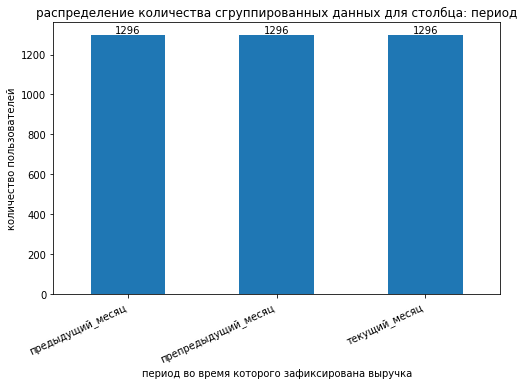

In [58]:
visualization(market_money,
              'период',
              'период во время которого зафиксирована выручка',
              num_col=False)

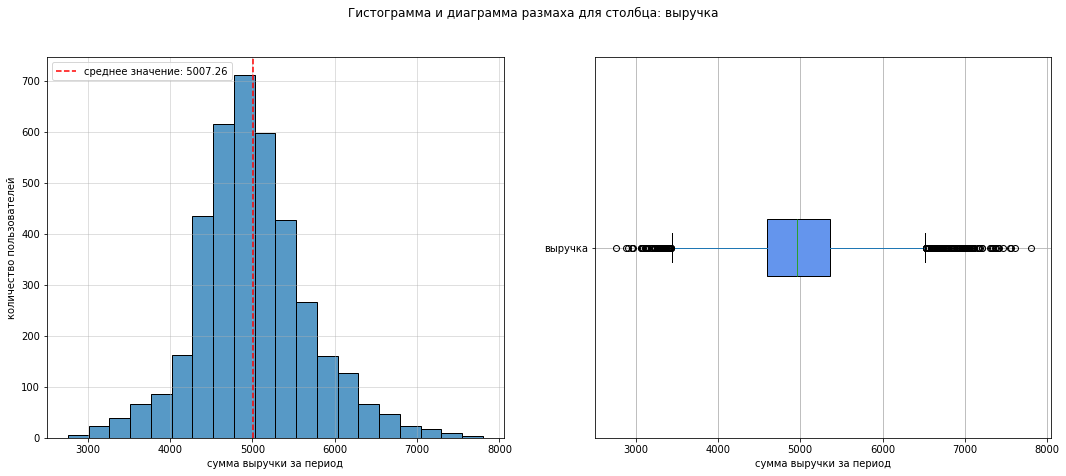

In [59]:
visualization(market_money,
              'выручка',
              'сумма выручки за период',
              num_col=True)

#### Графики для таблицы market_time

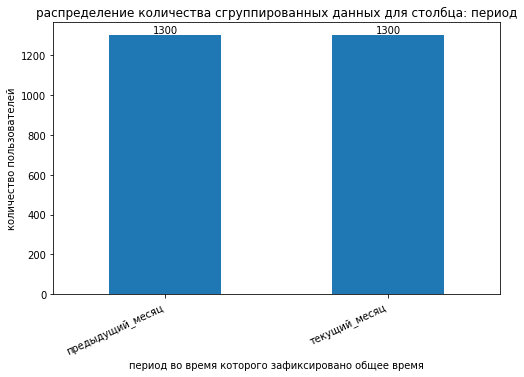

In [60]:
visualization(market_time,
              'период',
              'период во время которого зафиксировано общее время',
              num_col=False)

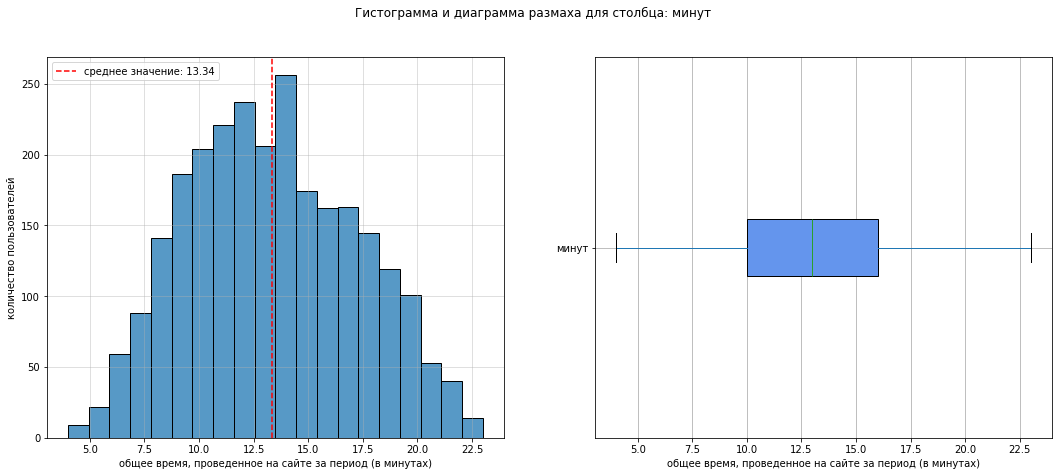

In [61]:
visualization(market_time,
              'минут',
              'общее время, проведенное на сайте за период (в минутах)',
              num_col=True)

#### График для таблицы money

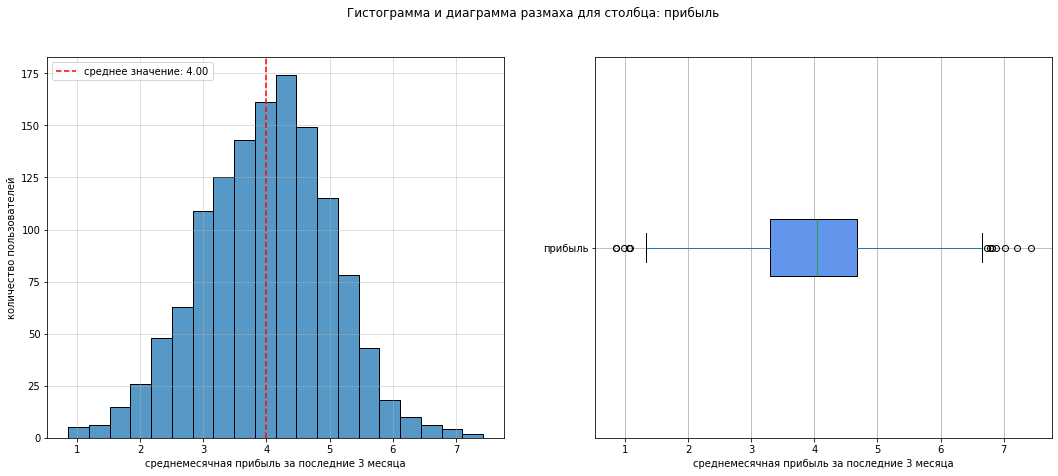

In [62]:
visualization(money,
              'прибыль',
              'среднемесячная прибыль за последние 3 месяца',
              num_col=True)

### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

В ходе статистического анализа данных выявлено максимальное значение выручки таблицы market_money, которое сильно выделялось среди остальных, скорее всего, оно ошибочно.\
Из таблицы удалены строки со значением выручки более 100000 

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам визуализации данных таблицы market_file установлено, что:
- у 38% клиентов, в представленных данных, снизился уровень покупательской активности;
- у ~29% клиентов уровень сервиса премиум, у 71% стандарт;
- 26% пользователей не дали разрешения на рассылку дополнительных предложений;
- график столбца маркет_актив_6_мес немного смещен вправо, со средним значением 4.25. Также в данных есть пропущенные значения в диапазоне 1.7 – 2.4;
- данные столбца маркет_актив_тек_мес больше похожи на категориальный признак, т.к в данных всего три уникальных значения;
-  среднее значение количества дней, прошедших с момента регистрации, составляет 601.9;
- график для столбца акционные_покупки смещен влево, со средним значением 0.32. В диапазоне от 0.4 до 0.89 в данных всего 6 значений. Данный признак изменен на бинарный категориальный – у 87 % пользователей низкая доля акционных покупок; 
- самой популярной категорией товаров является «товары для детей» (популярна у 25% пользователей)
- категория «товары для детей» является самой популярной у 25% пользователей. Всего в данных 6 популярных категорий: домашний текстиль (популярна у ~19.3%), косметика и аксессуары (популярна у ~17.2%), кухонная посуда (популярна у 11%), мелкая бытовая техника и электроника (популярна у ~13.4%), техника для красоты и здоровья (популярна у ~14.1%)
- в столбце средний_просмотр_категорий_за_визит присутствует 6 дискретных значений. Среднее количество просмотренных в течение месяца категорий пользователями: 3.27;
-  в столбце неоплаченные_продукты_штук_квартал присутствует 11 дискретных значений. У 49% пользователей количество неоплаченных продуктов за квартал находится в диапазоне от 0 до 2 шт. Среднее количество неоплаченных продуктов - 2.84;
- в столбце ошибка_сервиса присутствует 10 дискретных значений. Среднее количество ошибок - 4.19;
- в столбце страниц_за_визит присутствует 20 дискретных значений. Среднее количество просмотренных за визит страниц - 8.18.


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Перед визуализацией данных таблицы market_money были отобраны пользователи, которые совершали покупки в каждый период в представленных данных.\
\
Далее проведена визуализация обновленной таблицы в ходе которой установлено, что:
- количество покупок распределено равномерно по всем периодам, представленным в данных;
- график для столбца выручка распределен нормально, со средним значением 5007.26.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам визуализации данных таблицы market_time установлено, что:
- количество пользователей равномерно распределено по двум периодам, представленным в данных;
- среднее значение общего времени, проведенного на сайте за период, составляет 13.34.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам визуализации данных таблицы money установлено, что:
- график столбца прибыль немного смещен вправо, со средним значением 4.

## Шаг 4. Объединение таблиц

В данном разделе будет проведена работа по объединению таблиц market_file, market_money и market_time.\
В объединенной таблице данные о выручке (таблица market_money) и времени, проведенном на сайта в течение периода (таблица market_time), будут разделены по столбцам, исходя из представленных периодов.

\
Перед объединением данных разделим данные по периодам в таблицах market_money и market_time

In [63]:
# сводная таблица пользователей и соответствующей выручкой по периодам
money_by_period = market_money.pivot_table(index='id', columns='период', values='выручка').reset_index()

In [64]:
# Переименование столбцов таблицы money_by_period
money_by_period = money_by_period.rename(
    columns={
        'предыдущий_месяц' : 'предыдущий_месяц_выручка',
        'препредыдущий_месяц' : 'препредыдущий_месяц_выручка',
        'текущий_месяц' : 'текущий_месяц_выручка'
    }
)
money_by_period.head()       

период,id,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка
0,215349,5216.0,4472.0,4971.6
1,215350,5457.5,4826.0,5058.4
2,215351,6158.0,4793.0,6610.4
3,215352,5807.5,4594.0,5872.5
4,215353,4738.5,5124.0,5388.5


In [65]:
# сводная таблица пользователей и соответствующего времени по периодам
time_by_period = market_time.pivot_table(index='id', columns='период', values='минут').reset_index()

In [66]:
# Переименование столбцов таблицы time_by_period
time_by_period = time_by_period.rename(
    columns={
        'предыдущий_месяц' : 'предыдущий_месяц_минут',
        'текущий_месяц' : 'текущий_месяц_минут'
    }
)
time_by_period.head()

период,id,предыдущий_месяц_минут,текущий_месяц_минут
0,215348,13.0,14.0
1,215349,12.0,10.0
2,215350,8.0,13.0
3,215351,11.0,13.0
4,215352,8.0,11.0


\
Проведем объединение таблиц.\
Сначала объединим таблицы market_file и money_by_period, чтобы в итоговую таблицу вошли id покупателей из money_by_period.\
Затем получившуюся таблицу объединим с time_by_period

In [67]:
data_intr = market_file.merge(money_by_period, on='id', how='right')
data = data_intr.merge(time_by_period, on='id', how='left')

# установим значения id в качестве индексов
data = data.set_index('id')

In [68]:
data.head()

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут
id,,,,,,,,,,,,,,,,,
215349,снизилась,премиум,да,4.4,4,819,большая_доля,товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12.0,10.0
215350,снизилась,стандарт,нет,4.9,3,539,маленькая_доля,домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8.0,13.0
215351,снизилась,стандарт,да,3.2,5,896,большая_доля,товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11.0,13.0
215352,снизилась,стандарт,нет,5.1,3,1064,большая_доля,товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8.0,11.0
215353,снизилась,стандарт,да,3.3,4,762,маленькая_доля,домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10.0,10.0


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296 entries, 215349 to 216647
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   покупательская_активность            1296 non-null   object 
 1   тип_сервиса                          1296 non-null   object 
 2   разрешить_сообщать                   1296 non-null   object 
 3   маркет_актив_6_мес                   1296 non-null   float64
 4   маркет_актив_тек_мес                 1296 non-null   int64  
 5   длительность                         1296 non-null   int64  
 6   акционные_покупки                    1296 non-null   object 
 7   популярная_категория                 1296 non-null   object 
 8   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 9   неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 10  ошибка_сервиса                       1296 non-null   int64  
 11  страниц_за_визит            

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

**Вывод**\
На данном этапе проведена работа по объединению таблиц market_file, market_money и market_time.\
В итоговой таблице периоды из таблиц market_money и market_time сделали отдельными столбцами с присвоением соответствующих наименований.

## Шаг 5. Корреляционный анализ

In [70]:
interval_cols = ['маркет_актив_6_мес', 'длительность',
                 'предыдущий_месяц_выручка', 'препредыдущий_месяц_выручка', 
                 'текущий_месяц_выручка', 'предыдущий_месяц_минут',
                 'текущий_месяц_минут'
                ]

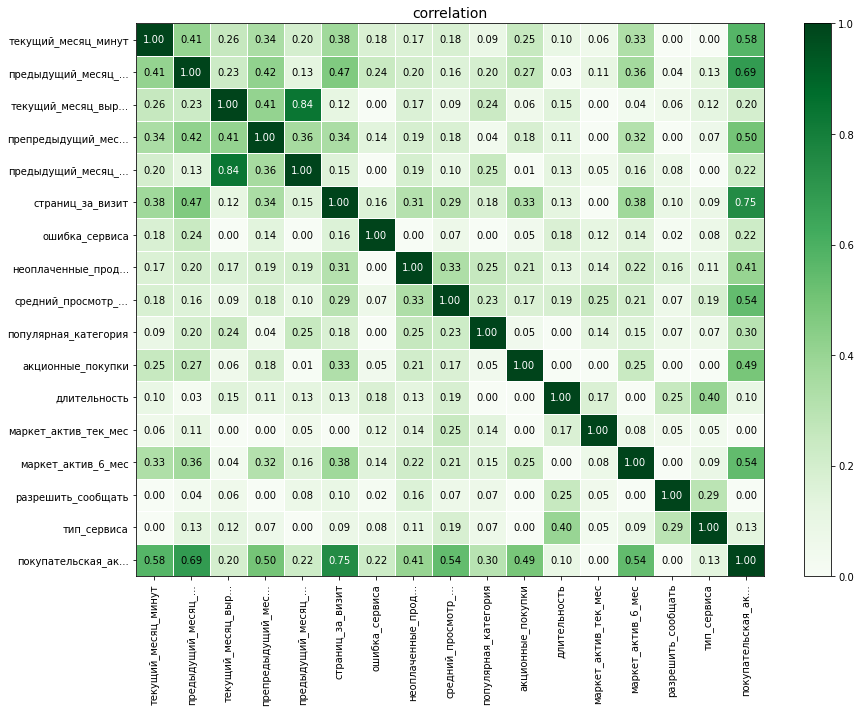

In [71]:
data_plot = data.phik_matrix(interval_cols=interval_cols)
plot_correlation_matrix(data_plot.values,
                        x_labels=data_plot.columns,
                        y_labels=data_plot.index,
                        vmin=0, vmax=1, color_map='Greens',
                        figsize=(13, 10));

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

**Вывод**\
По результатам визуализации матрицы корреляции установлено, что между признаками отсутствует мультиколлинеарность (при пороге корреляции от 0.9)

## Шаг 6. Использование пайплайнов

В данном разделе будет проведена работа по подбору лечшей модели классфикации и метрики оценки качества работы модели.\
Для подбора модели, гиперпараметров будет использован пайплайн

Т.к. в данных присутствует дисбаланс классов целевого признака, то для оценки работы модели будет использована метрика roc_auc (будет выбрана модель с наивысшим значением метрики)

\
Разделим данные на тренировочную и тестовую выборки с использованием стратификации

In [72]:
# сохранение признаков и разделение на тренировочную и тестовую выборки
X = data.drop(['покупательская_активность'], axis=1)
y = data['покупательская_активность']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [73]:
# проверка размерности
X_train.shape, X_test.shape

((1036, 16), (260, 16))

In [74]:
# кодирование целевого признака (столбец покупательская_активность)
lab_encoder = LabelEncoder()
y_train = lab_encoder.fit_transform(y_train)
y_test = lab_encoder.transform(y_test)

In [75]:
# расшифровка закодированных значений
lab_encoder.inverse_transform([0, 1])

array(['прежний уровень', 'снизилась'], dtype=object)

### Пайплайны подготовки данных

В данном шаге будет проведена работа по:
- определению вида кодирования для категориальных признаков;
- написанию пайплайнов подготовки данных.

In [76]:
# признаки для кодирования OneHotEncoder
ohe_col = ['тип_сервиса', 'разрешить_сообщать', 'популярная_категория']

# признаки для кодирования OrdinalEncoder
ord_col = ['акционные_покупки']

# количественные признаки 
num_col = data.drop('покупательская_активность', axis=1).select_dtypes(include='number').columns.tolist()

In [77]:
# пайплайн для подготовки признаков из списка ohe_col
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe',
         SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        ('ohe',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        )
    ]
)

In [78]:
# пайплайн для подготовки признаков из списка ord_col
ord_pipe = Pipeline(
    [
        ('simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        ('ord',  
            OrdinalEncoder(
                categories=[
                    ['маленькая_доля', 'большая_доля']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        ('simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

In [79]:
# итоговый пайплайн подготовки данных
data_preprocessor = ColumnTransformer(
    [
    ('ohe', ohe_pipe, ohe_col),
    ('ord', ord_pipe, ord_col),
    ('num', MinMaxScaler(), num_col)
    ],
    remainder='passthrough'
)

In [80]:

# пайплайн содержащий подготовку данных и инициализацию модели МО
final_pipe = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('model', LogisticRegression(random_state=RANDOM_STATE))
    ]
)


### Подбор лучшей модели МО

В данном шаге будет проведен подбор лучшей модели МО с учетом разных гиперпараметров 

In [81]:
# выбор гиперпараметров для моделей
param_grid = [
    # параметры для модели LogisticRegression
    {
        'model': [LogisticRegression(random_state=RANDOM_STATE)],
        'model__penalty': ['l1', 'l2'],
        'model__solver' : ['liblinear', 'saga'],
        'model__class_weight' : ['balanced'],
        'model__C' : range(1, 6),
        'preprocessor__num' : [StandardScaler(), MinMaxScaler()
                              ]
    },
    # параметры для модели Support Vector Machines
    {
        'model' : [SVC(random_state=RANDOM_STATE, probability=True)],
        'model__kernel': ['rbf', 'sigmoid', 'poly'],
        'model__degree' : range(2, 7),
        'model__class_weight' : ['balanced'],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler(),
                               'passthrough']
    },
    #  параметры для модели KNeighborsClassifier
    {
        'model' : [KNeighborsClassifier()],
        'model__n_neighbors' : range(3, 8),
        'preprocessor__num' : [StandardScaler(), MinMaxScaler(),
                               'passthrough']
    },
    # параметры для модели DecisionTreeClassifier
    {
        'model' : [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth' : range(2, 8),
        'model__min_samples_split' : range(2, 6),
        'model__min_samples_leaf' : range(1, 6),
        'model__class_weight' : ['balanced'],
        'preprocessor__num' : [StandardScaler(), MinMaxScaler(),
                               'passthrough']
 
    }
]

In [82]:
start = time.time()
# инициализация класса RandomizedSearchCV для подбора модели и гиперпараметров
randomized_search = RandomizedSearchCV(
    final_pipe,
    param_grid,
    scoring='roc_auc',
    n_jobs=1,
    cv=5,
    random_state=RANDOM_STATE
)

randomized_search.fit(X_train, y_train)

# считаем, сколько секунд прошло с начала запуска
loop_search_time = time.time() - start
print(f'Search time:{loop_search_time}')

print('Лучшая модель и её параметры:\n', randomized_search.best_estimator_.named_steps['model'])
print ('Метрика лучшей модели при кросс-валидации:', randomized_search.best_score_)


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Search time:2.4425840377807617
Лучшая модель и её параметры:
 LogisticRegression(C=4, class_weight='balanced', random_state=42, solver='saga')
Метрика лучшей модели при кросс-валидации: 0.902221782700422


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [83]:

y_test_pred_rand = randomized_search.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred_rand)}')


Метрика ROC-AUC на тестовой выборке: 0.9082125603864735


### Вывод

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

1. В данном шаге проведена работа по:
- написанию пайплайнов для подготовки данных и инициализации модели МО;
- определению гиперпараметров для тестирования четырех моделей МО (LogisticRegression, SVC, KNeinhborsClassifier, DecisionTreeClassifier).

2. В качестве метрики выбрана roc_auc, т.к. не стоит задача с максимально возможной точностью предсказать снижение покупательской активности клиента, а также не было сообщено об ограничении бюджета на разработку персонализированных предложений

3. По результатам тестирования моделей МО с различными гиперпараметрами с использованием класса RandomizedSearchCV:
- лучшей моделью оказалась LogisticRegression с гиперпараметрами C=4, class_weight='balanced', random_state=42, solver='saga'

## Шаг 7. Анализ важности признаков

В данном разделе будет проведена работа по оценке важности признаков для выбранной модели МО

In [84]:
# инициализация модели с лучшими гиперпараметрами
model = randomized_search.best_estimator_.named_steps['model']

In [85]:
# нименования преобразованных признаков
columns = randomized_search.best_estimator_.named_steps['preprocessor']\
    .get_feature_names_out()

In [86]:
# кодирование и масштабирование признаков из тренировочной выборки
X_train_conv = pd.DataFrame(
    randomized_search.best_estimator_['preprocessor'].transform(X_train),
    columns=columns
)

In [87]:
# кодирование и масштабирование признаков из тестовой выборки
X_test_conv = pd.DataFrame(
    randomized_search.best_estimator_['preprocessor'].transform(X_test),
    columns=columns
)

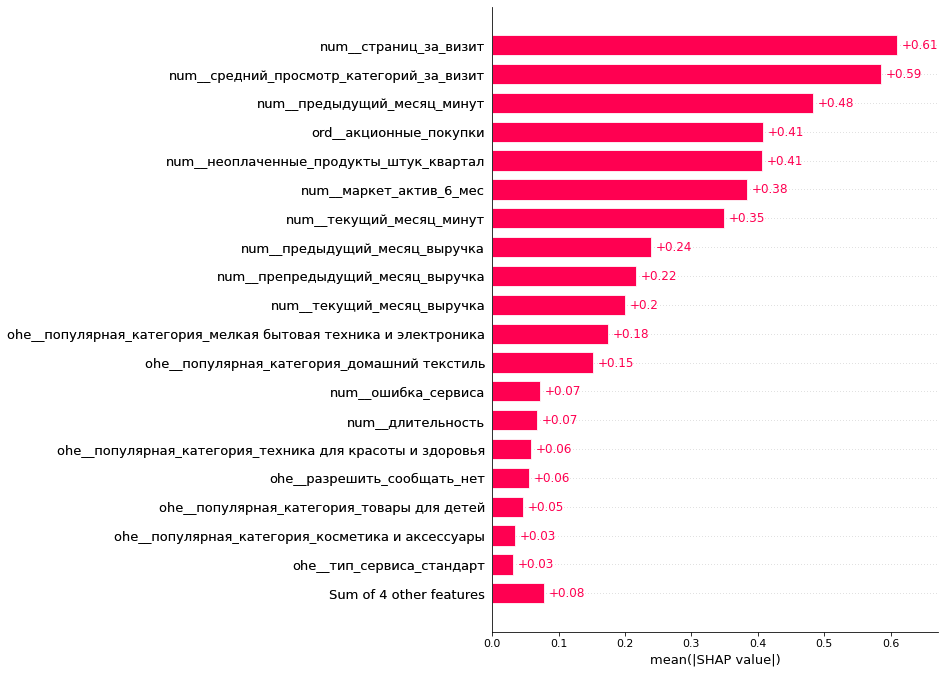

In [88]:
explainer = shap.LinearExplainer(model, X_test_conv)
shap_values = explainer(X_test_conv)
shap.plots.bar(shap_values, max_display=20) 

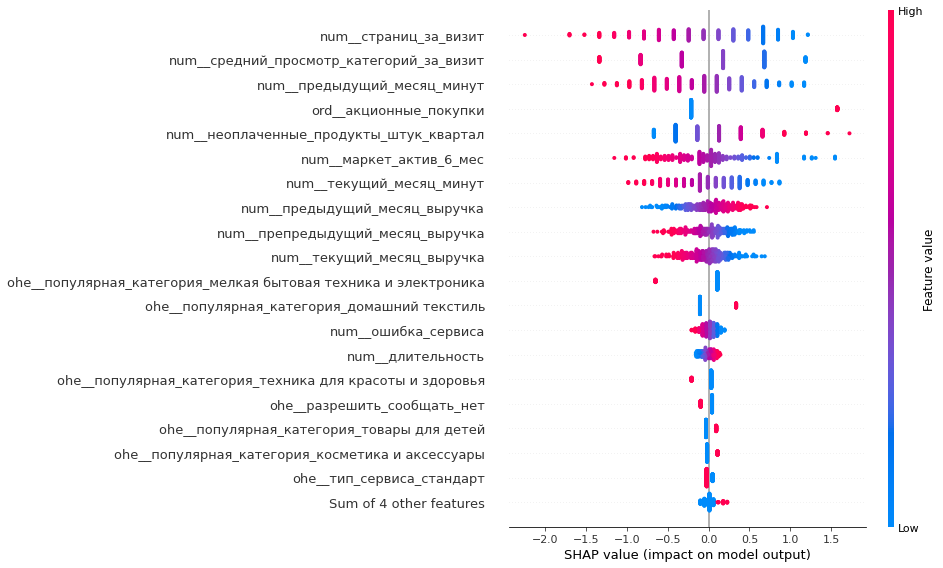

In [89]:
shap.plots.beeswarm(shap_values, max_display=20)

### Вывод

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

- Самым важным для модели оказался признак «страниц_за_визит», из которого логично вытекают несколько других значимых признака «средний_просмотр_категорий_за_визит» (второй по значимости), «предыдущий_месяц_минут» (третий по значимости) и «текущий_месяц_минут» (седьмой по значимости).

Высокие значения данных признаков (данные диаграммы shap.plots.beeswarm) указывают на то, что чем больше данные показатели, тем вероятнее у клиента не снизится активность в последующие периоды.\
Возможно, это связано с некорректной работой поисковой системы, на конкретный запрос в подборке присутствует большое количество ненужных, в данный момент, товаров (товары продавцов, заплативших за продвижение товаров, либо неправильно оформленные товары (отнесенные не к своей категории), что вынуждает просматривать большое количество страниц в поисках запрашиваемого и находить доолнительный интересные товары.

- На четвертом по важности месте оказался признак «неоплаченные_продукты_штук_квартал».

Вероятно, данный признак связан с еще одним значимым для модели – «акционные_покупки» (пятый по значимости), высокие значения данных признаков указываю на то, что у пользователей снизится активность в последующие периоды.\
Вероятно, это связано с добавлением товара в корзину и ожиданием акционной цены на него.\
Высокие значения данных признаков указывают на то, что у клиентов снизится активность в последующие периоды
\
- Самыми малозначимы оказались признаки: «маркет_актив_тек_мес» и «тип_сервиса_стандарт».

- При принятии бизнес-решений необходимо соблюсти баланс между продвижением товаров продавцов и показом в поисковом запросе товаров соответствующих конкретному запросу (необходимо провести тесты и выявить границу баланса между прибылью от продвижения товаров и удовлетворенностью клиентов от затраченного времени на поиск необходимого товара).


## Шаг 8. Сегментация покупателей

В данном разделе будет проведена работа по сегментации покупателей на основании прогнозных данных выбранной модели МО и данных о прибыльности покупателей.\
\
На основании сегментации для проведения исследования будет выбрана группа покупателей с высокой вероятностью снижения покупательской активности в последующие периоды


### Сегментация покупателей

Перед сегментаций проведем объединение данных тренировочной и тестовой выборок, а также добавим столбцы с предсказанной вероятностью и предсказанным классом целевого признака (покупательская активность)

In [90]:
# предсказанные вероятности для тренировочной и тестовой выборок
y_train_proba = model.predict_proba(X_train_conv)[:, 1]
y_test_proba = model.predict_proba(X_test_conv)[:, 1]

# пердсказание класса для тренировочной и тестовой выборок
y_train_pred = model.predict(X_train_conv)
y_test_pred = model.predict(X_test_conv)

# добавление предсказанных вероятностей и классов
# к тренировочной и тестовой выборкам
X_train['предсказанная_вероятность'] = y_train_proba
X_train['предсказанный_класс'] = y_train_pred
X_test['предсказанная_вероятность'] = y_test_proba
X_test['предсказанный_класс'] = y_test_pred

# объединение данных тренировочной и тестовой выборок
data = pd.concat([X_train, X_test])

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [91]:
# установимв таблице money значения id в качестве индексов
money = money.set_index('id')

In [92]:
# объединеним таблицы data и money
data = data.join(money)

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296 entries, 215884 to 215633
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   тип_сервиса                          1296 non-null   object 
 1   разрешить_сообщать                   1296 non-null   object 
 2   маркет_актив_6_мес                   1296 non-null   float64
 3   маркет_актив_тек_мес                 1296 non-null   int64  
 4   длительность                         1296 non-null   int64  
 5   акционные_покупки                    1296 non-null   object 
 6   популярная_категория                 1296 non-null   object 
 7   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 8   неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 9   ошибка_сервиса                       1296 non-null   int64  
 10  страниц_за_визит                     1296 non-null   int64  
 11  предыдущий_месяц_выручка    

\
Построим графики зависимости вероятности снижения покупательской активности от прибыльности покупателей с учетом значений категориальных признаков

In [94]:
cat_col = ['тип_сервиса', 'разрешить_сообщать', 'акционные_покупки',  'популярная_категория']

In [95]:
# Напишем функцию для построения диаграмм рассеяния
def plot_scatter_by_categories(df, y_col, x_col, cat_col):
    """
    Функция построения scatter plots между значением вероятности
    снижения покупательской активности и прибыльностью клиента
    с учётом значений категориальных признаков,
    разбивая данные по категориальным признакам из cat_col.
   
    Параметры:
    df - датафрейм.
    y_col - прибыльность клиента (ось Y).
    x_col - значение вероятности снижения покупательской активности (ось X).
    cat_col - список категориальных признаков (для группировки).
    """

    for col in cat_col:        
        # Создаем subplot
        fig = plt.subplots(figsize=(14, 8))
        plt.title(f"зависимость между"\
                  f" значением вероятности снижения покупательской активности и прибыльностью клиента"\
                  f" с учётом значения категориального признака {col}", fontsize=10,  y=1.02)
           
        # Строим scatter plot для каждого категориального признака
        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=col,
            alpha=0.5
            )
    
        # настройка графика
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.legend(title=col, bbox_to_anchor=(-0.1, 1), loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
           
        plt.tight_layout()
        plt.show()

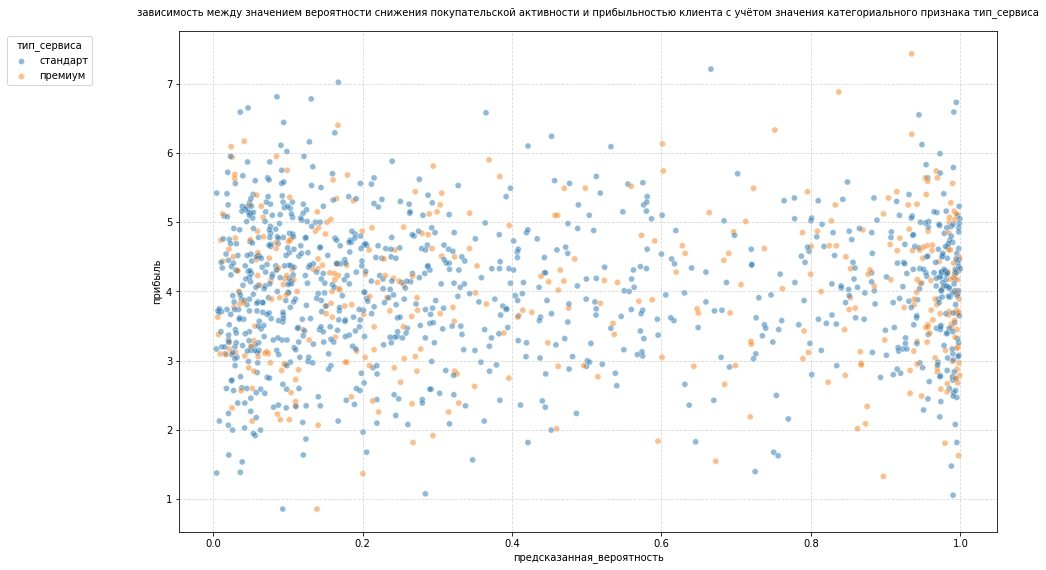

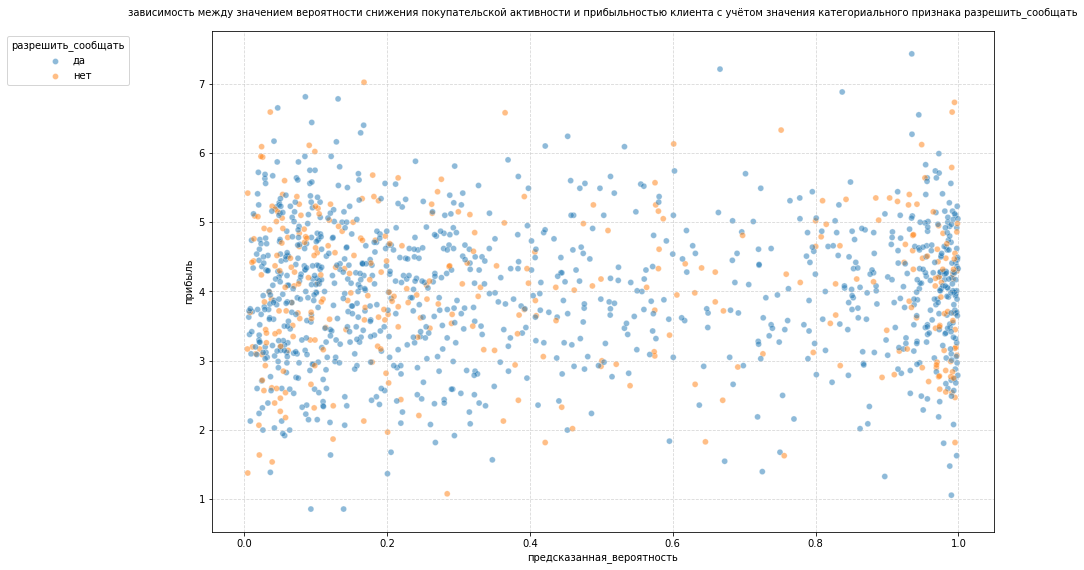

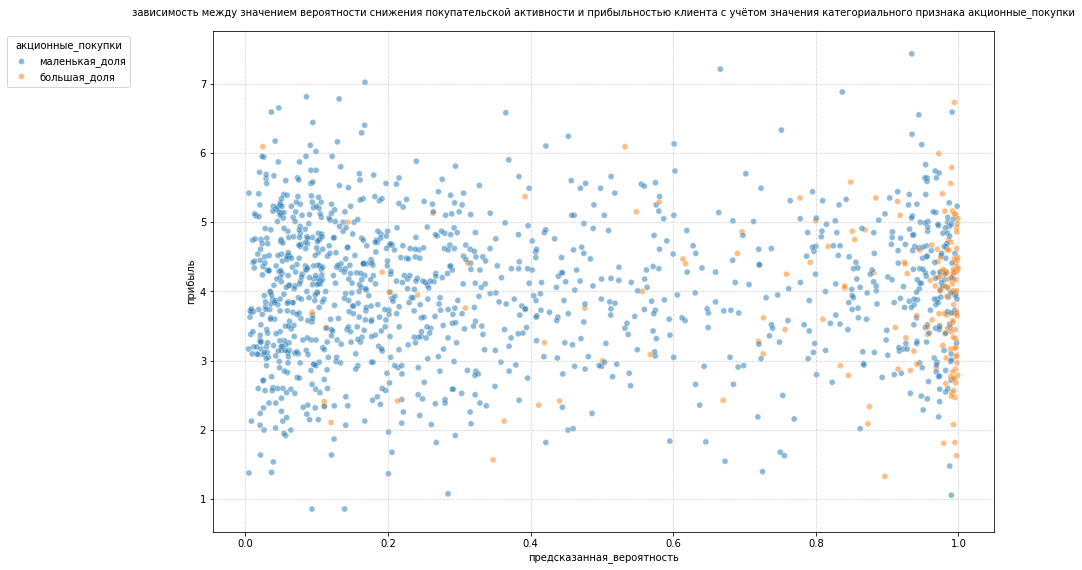

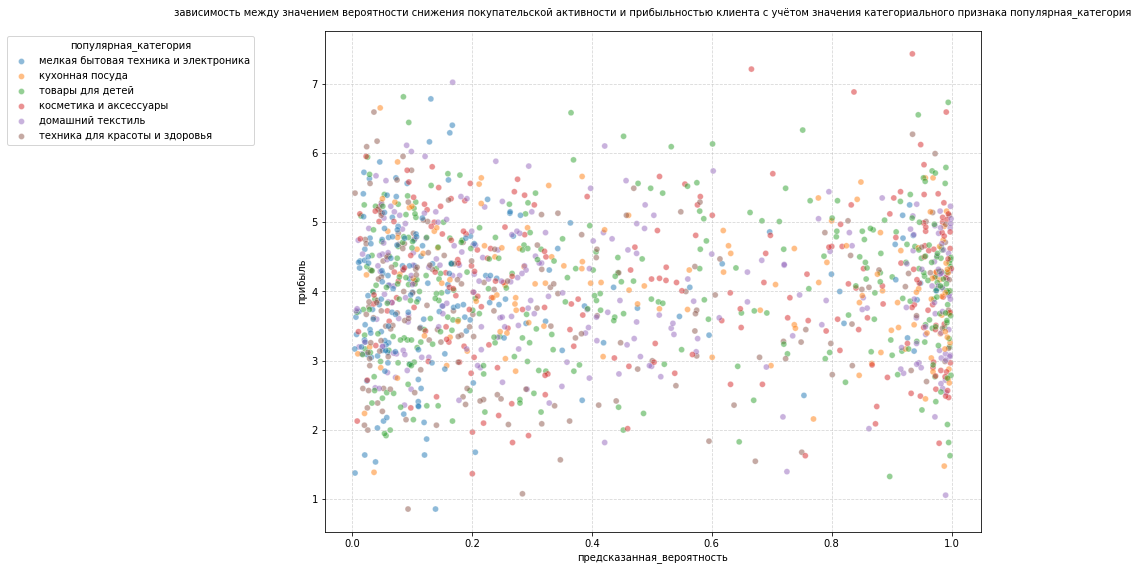

In [96]:
plot_scatter_by_categories(data, 'прибыль', 'предсказанная_вероятность', cat_col)

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

В результате визуализации данных зависимости между значениями вероятности снижения покупательской активности и прибыльностью клиента 
с учётом значений категориальных признаков:
- удалось выделить сегмент покупателей с большой долей покупок по акции и большой вероятностью снижения покупательской активности

### Исследование выбранной группы покупателей

Для сранительного анализа построим графики для визуализации распределения данных между пользователями с большой долей покупок по акции и отнесенных к классу тех, у кого снизится покупательская активность и остальными пользователями

Создадим два датафрейма:
- с пользователями выбранного сегмента;
- с остальными пользователями

In [97]:
# отбор исследуемой группы пользователей
data_segment = data.query('(акционные_покупки == "большая_доля") and (предсказанный_класс == 1)')

# датафрейм с остальными пользователями
data_other = data.drop(data_segment.index)

\
Для визуализации создадим список количественных признаков num_col (не включая столбцы предсказанная_вероятность и предсказанный_класс), а также список категориальных признаков cat_col

In [98]:
# список количественных признаков num_col
num_col = data.select_dtypes(include='number').columns.tolist()

# удалим из num_col стобцы редсказанная_вероятность и предсказанный_класс
del_col = ['предсказанная_вероятность', 'предсказанный_класс']
num_col = [col for col in num_col if col not in del_col]

# список категориальных признаков num_col
cat_col = data.select_dtypes(include='object').columns.tolist()

Напишем функцию для визуализации данных

In [99]:
def visualization_comparison_num (data_segment, data_other, column):
    '''
    функция визуализации количественных столбцов двух датафреймов
    для сравнительного ананлиза
    data_segment, data_other - датафреймы
    column - столбец для данных которого строится график
    '''
    plt.figure(figsize=(8, 6))

    sns.histplot(data_other[column], bins=30, alpha=0.5,
                 color='y', label='остальные пользователи')
    sns.histplot(data_segment[column], bins=30, alpha=0.6,
                 color='b', label='отобранный сегмент')
    
    # добавление линий медиан
    plt.axvline(np.mean(data_segment[column]), linestyle='--', linewidth=1.5,
                label=(f'среднее для отобранного сегмента '
                       f'{round(np.mean(data_segment[column]), 2)}'))
    plt.axvline(np.mean(data_other[column]), linestyle='--', linewidth=1.5,
                color='r', label=(f'среднее для отсальных пользователей ' 
                                  f'{round(np.mean(data_other[column]), 2)}'))
    
    # настройка графика
    plt.title(f'гистограммы для столбца {column}')
    plt.xlabel(f'значение {column}')
    plt.ylabel('количество пользователей')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()

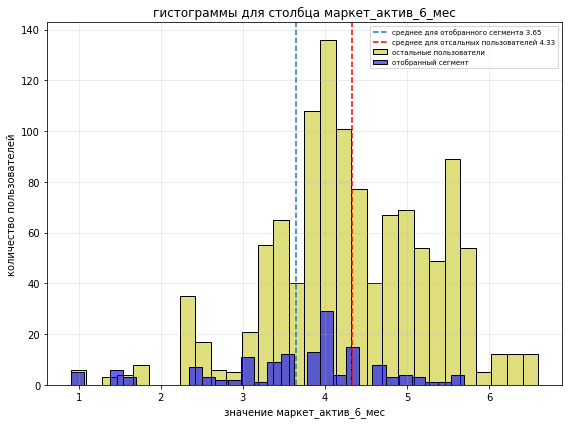

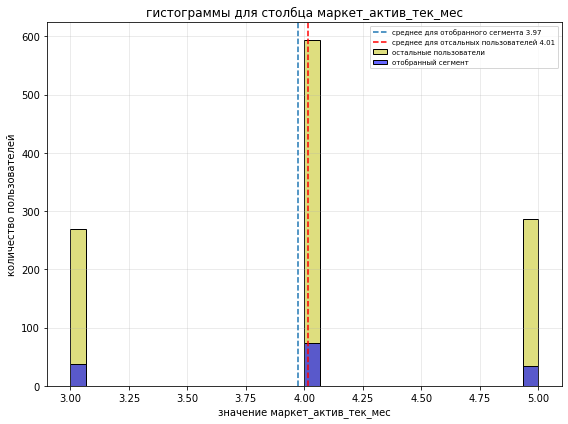

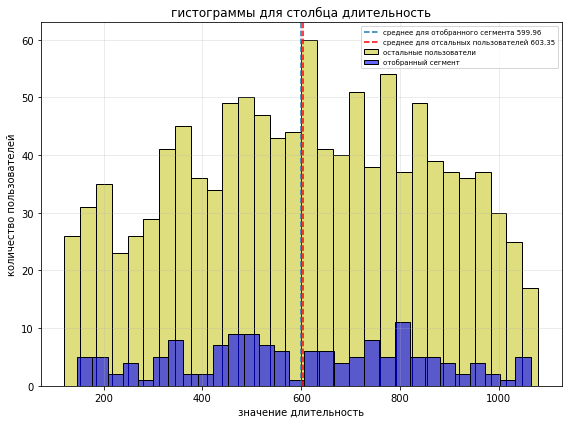

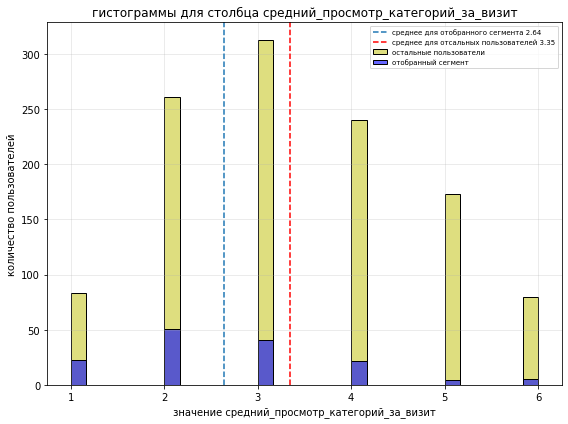

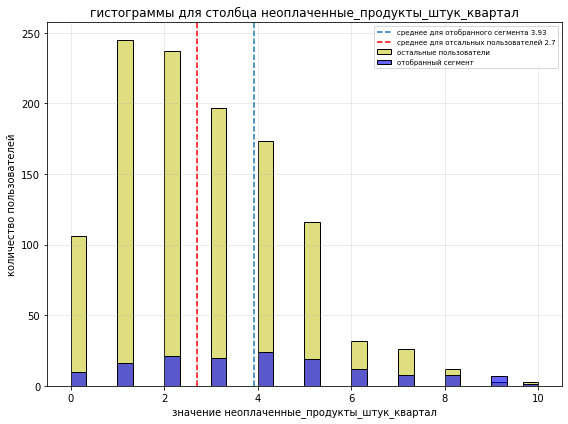

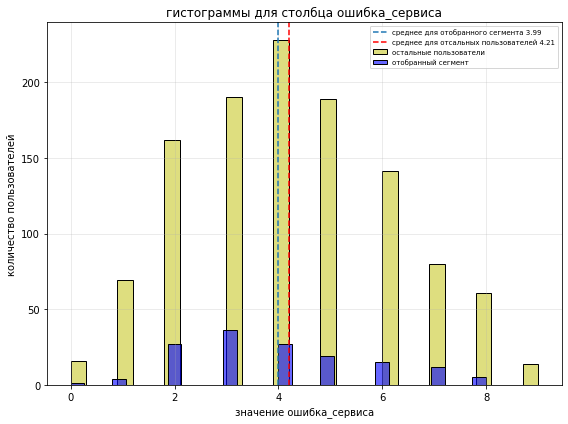

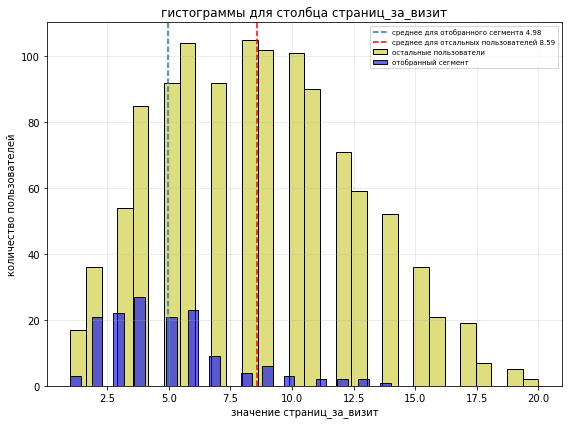

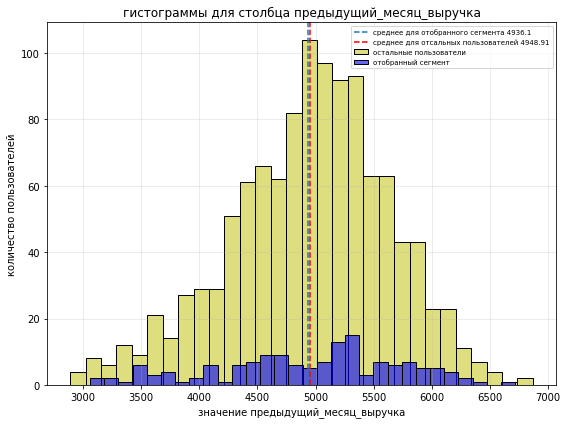

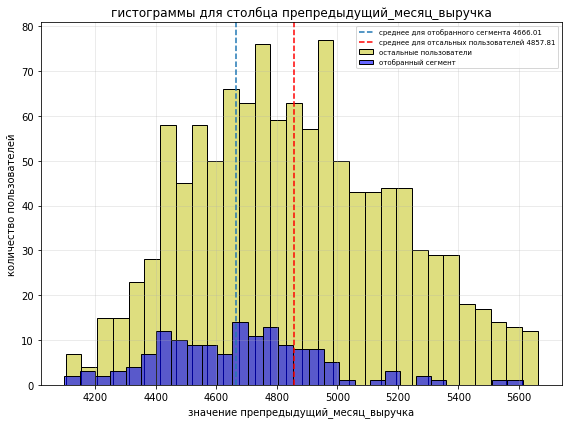

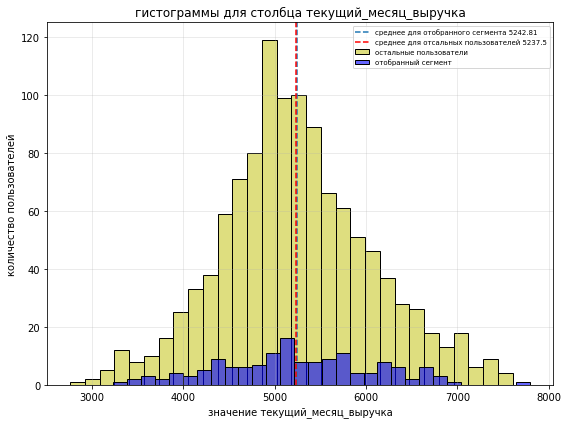

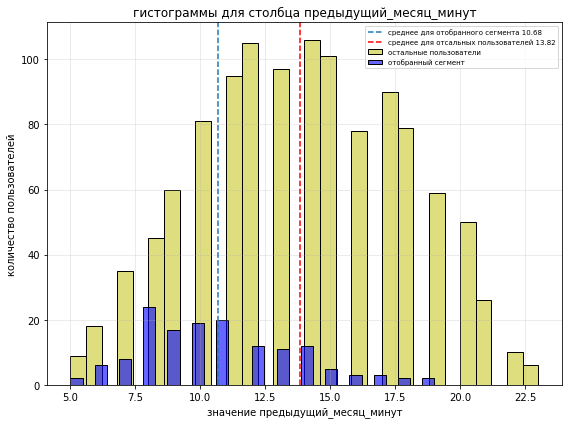

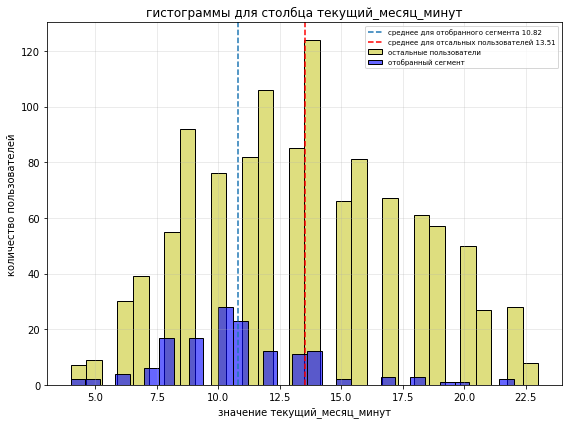

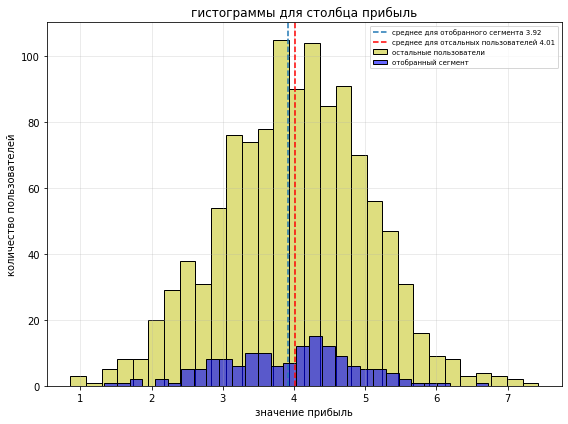

In [100]:
for col in num_col:
    visualization_comparison_num(data_segment, data_other, column=col)

In [101]:
def visualization_comparison_cat (data_segment, data_other, column):
    '''
    функция визуализации категориальных столбцов двух датафреймов
    для сравнительного ананлиза
    data_segment, data_other - датафреймы
    column - столбец для данных которого строится график
    '''
    plt.figure(figsize=(8, 6))

    ax = data_segment.groupby(column)[column].count().plot(
        kind='bar',
        xlabel=column,
        color='blue',
        width=0.5,
        label='отобранный сегмент'
    )
    
    data_other.groupby(column)[column].count().plot(
        kind='bar',
        y=column,
        alpha=0.6,
        color='green',
        ax=ax,
        label='остальные пользователи'
    )
    
    # настройка графика
     # настройка графика
    ax.set_title(f'распределение количества сгруппированных данных для столбца: {column}')
    plt.xlabel(column)
    plt.ylabel('количество пользователей')
    plt.grid(alpha=0.3)
    ax.legend(fontsize=7)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # подпись количества пользователей
    for bar_group in ax.containers:
        ax.bar_label(bar_group, label_type='edge')

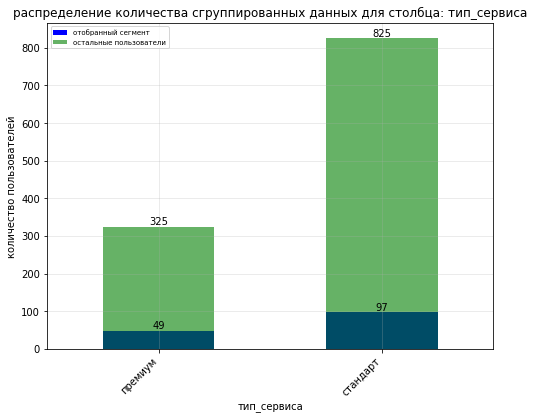

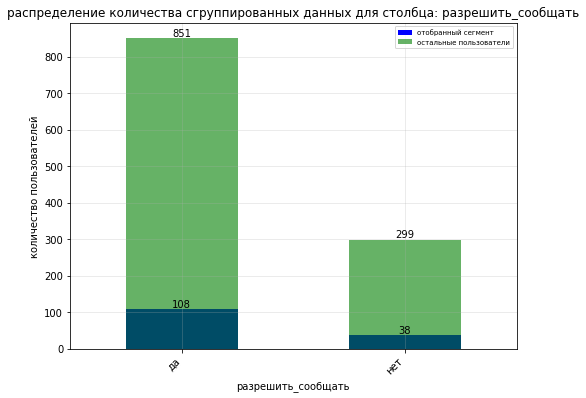

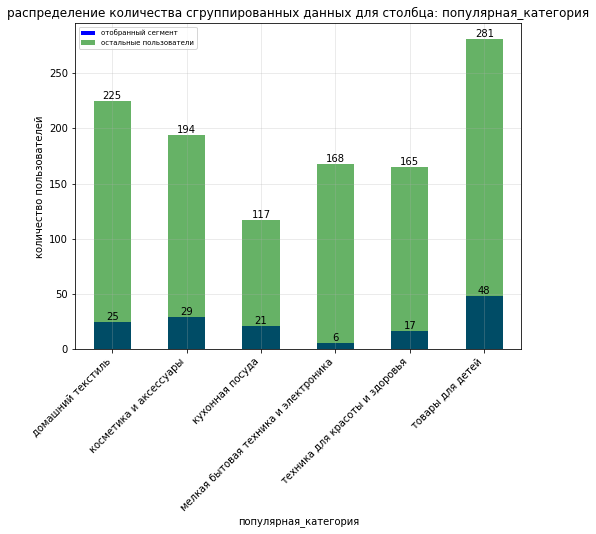

In [102]:
for col in cat_col:
    if col != 'акционные_покупки':
        visualization_comparison_cat(data_segment, data_other, col)

### Вывод

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам визуализации данных установлено, что:
- у отобранного сегмента пользователей среднемесячное количество маркетинговых коммуникаций за последние 6 месяцев меньше, чем у остальных пользователей. Но в текущем месяце у двух групп пользователей (отобранные и остальные) количество маркетинговых коммуникаций распределено одинаково.
- у отобранного сегмента пользователей среднее количество просмотренных категорий за визит (в течение последнего месяца) и среднее количество просмотренных за визит страниц (за последние 3 месяца) меньше, чем у остальных пользователей.
- Самой популярной категорией у отобранного сегмента пользователей (как и у остальных) является «товары для детей».
- А т. к. количество неоплаченных товаров в корзине больше у отобранного сегмента пользователей, можно сделать вывод о том, что, вероятнее всего, данные пользователи ищут определенные товары, добавляют их в корзину и ждут снижения цены.


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Для увеличения покупательской активности выбранного сегмента пользователей можно:
- персонализировать скидки на товары самой популярной категории "товары для детей" на главной странице. Также можно обновлять акционные товары на главном жкране прикаждом заходе в приложение (для увеличения вовлеченности)
- при поиске товаров предлагать персонализированные (для данного сегмента) акции и скидки на товары менее популярных категорий "косметика и аксессуары" и "домашний текстиль".


## Шаг 9. Общий вывод

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

**Поставленная задача**\
Разработать модель МО предсказывающую снижение покупательской активности пользователей с целью разработки для них персонализированных предложений.

**В процессе работы над проектом:**
1. была проведена работа по изучению данных (в данных не обнаружено пропущенных значений).
2. проведена предварительная обработка данных:
    - строковые значения датафреймов приведены к нижнему регистру;
    - изменен тип данных с `object` на `float` в столбце `Прибыль` таблицы money;
    - удалены неявные дубликаты из таблицы market_file;
    - исправлено значение в столбце период таблицы market_time;
    - исправлено значение в столбце популярная_категория таблицы market_file.

\
3. Проведен исследовательский анализ данных:
- По результатам визуализации данных таблицы market_file установлено:
    - у 38% клиентов, в представленных данных, снизился уровень покупательской активности;
    - у ~29% клиентов уровень сервиса премиум, у 71% стандарт;
    - 26% пользователей не дали разрешения на рассылку дополнительных предложений;
    - график столбца маркет_актив_6_мес немного смещен вправо, со средним значением 4.25. Также в данных есть   пропущенные значения в диапазоне 1.7 – 2.4;
    - в данных столбца маркет_актив_тек_мес всего три уникальных значения;
    -  график для столбца длительность распределен нормально, со средним значением 601.9;
    - график для столбца акционные_покупки смещен влево, со средним значением 0.32. В диапазоне от 0.4 до 0.89 в данных всего 6 значений. Значения данного переведены в категориальный бинарный признак, в качестве разделителя указано значение 0.5; 
    - самой популярной категорией товаров является «товары для детей» (популярна у 25% пользователей)
    - категория «товары для детей» является самой популярной у 25% пользователей. Всего в данных 6 популярных категорий: домашний текстиль (популярна у ~19.3%), косметика и аксессуары (популярна у ~17.2%), кухонная посуда (популярна у 11%), мелкая бытовая техника и электроника (популярна у ~13.4%), техника для красоты и здоровья (популярна у ~14.1%)
    - в столбце средний_просмотр_категорий_за_визит присутствует 6 дискретных значений. Среднее количество просмотренных в течение месяца категорий пользователями: 3.27;
    -  график столбца неоплаченные_продукты_штук_квартал смещен влево со средним значением 2.84;
    - график для столбца ошибка_сервиса распределен нормально, со средним значением 4.19;
    - график столбца страниц_за_визит смещен влево со средним значением 8.18.
- Перед визуализацией данных таблицы market_money были отобраны пользователи, которые совершали покупки в каждый период в представленных данных. Далее проведена визуализация обновленной таблицы в ходе которой установлено, что:
    - количество покупок распределено равномерно по всем периодам, представленным в данных;
    - график для столбца выручка распределен нормально, со средним значением 5007.26.
- По результатам визуализации данных таблицы market_time установлено, что:
    - количество пользователей равномерно распределено по двум периодам, представленным в данных;
    - график для столбца минут распределен нормально, со средним значением 13.34.
- По результатам визуализации данных таблицы money установлено, что:
    - график столбца прибыль немного смещен вправо, со средним значением 4.

\
4. Проведена работа по объединению таблиц market_file, market_money и market_time.\
В итоговой таблице периоды из таблиц market_money и market_time сделали отдельными столбцами с присвоением соответствующих наименований.

\
5. Проведен корреляционный анализ данных общей таблицы (после объединения). По результатам визуализации матрицы корреляции установлено, что между признаками отсутствует мультиколлинеарность (при пороге корреляции от 0.9)

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

6. Проведена работа по:
    - написанию пайплайнов для подготовки данных и инициализации модели МО;
    - определению гиперпараметров для тестирования четырех моделей МО (LogisticRegression, SVC, KNeinhborsClassifier, DecisionTreeClassifier).
    - В качестве метрики выбрана roc_auc, т.к. не стоит задача с максимально возможной точностью предсказать снижение покупательской активности клиента, а также не было сообщено об ограничении бюджета на разработку персонализированных предложений

- По результатам тестирования моделей МО с различными гиперпараметрами с использованием класса RandomizedSearchCV:
    - **лучшей моделью оказалась LogisticRegression с гиперпараметрами C=4, class_weight='balanced', random_state=42, solver='saga'**

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

7. Проведена работа по определению важности признаков для лучшей модели МО:
    - Самым важным для модели оказался признак «страниц_за_визит», из которого логично вытекают несколько других значимых признака «средний_просмотр_категорий_за_визит» (второй по значимости), «предыдущий_месяц_минут» (третий по значимости) и «текущий_месяц_минут» (седьмой по значимости).
    
    Высокие значения данных признаков (данные диаграммы shap.plots.beeswarm) указывают на то, что чем больше данные показатели, тем вероятнее у клиента не снизится активность в последующие периоды.\
    Возможно, это связано с некорректной работой поисковой системы, на конкретный запрос в подборке присутствует большое количество ненужных, в данный момент, товаров (товары продавцов, заплативших за продвижение товаров, либо неправильно оформленные товары (отнесенные не к своей категории), что вынуждает просматривать большое количество страниц в поисках запрашиваемого и находить доолнительный интересные товары.
    
    - На четвертом по важности месте оказался признак «неоплаченные_продукты_штук_квартал».
    
    Вероятно, данный признак связан с еще одним значимым для модели – «акционные_покупки» (пятый по значимости), высокие значения данных признаков указываю на то, что у пользователей снизится активность в последующие периоды. 
    Вероятно, это связано с добавлением товара в корзину и ожиданием акционной цены на него.\
    Высокие значения данных признаков указывают на то, что у клиентов снизится активность в последующие периоды
    
    - Самыми малозначимы оказались признаки: «маркет_актив_тек_мес» и «тип_сервиса_стандарт».
    
    - При принятии бизнес-решений необходимо соблюсти баланс между продвижением товаров продавцов и показом в поисковом запросе товаров соответствующих конкретному запросу (необходимо провести тесты и выявить границу баланса между прибылью от продвижения товаров и удовлетворенностью клиентов от затраченного времени на поиск необходимого товара).

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

8. Проведена работа по сегментации покупателей на основании прогнозных данных выбранной модели МО. Для графического и аналитического исследования выбран сегмент пользователей с большой долей покупок по акции и большой вероятностью снижения покупательской активности:
- По результатам визуализации данных установлено, что:
    - у отобранного сегмента пользователей среднемесячное количество маркетинговых коммуникаций за последние 6 месяцев меньше, чем у остальных пользователей. Но в текущем месяце у двух групп пользователей (отобранные и остальные) количество маркетинговых коммуникаций распределено одинаково.
    - у отобранного сегмента пользователей среднее количество просмотренных категорий за визит (в течение последнего месяца) и среднее количество просмотренных за визит страниц (за последние 3 месяца) меньше, чем у остальных пользователей.
    - Самой популярной категорией у отобранного сегмента пользователей (как и у остальных) является «товары для детей».
    - А т. к. количество неоплаченных товаров в корзине больше у отобранного сегмента пользователей, можно сделать вывод о том, что, вероятнее всего, данные пользователи ищут определенные товары, добавляют их в корзину и ждут снижения цены.

\
Для увеличения покупательской активности выбранного сегмента пользователей можно:
- персонализировать скидки на товары самой популярной категории "товары для детей" на главной странице. Также можно обновлять акционные товары на главном жкране прикаждом заходе в приложение (для увеличения вовлеченности)
- при поиске товаров предлагать персонализированные (для данного сегмента) акции и скидки на товары менее популярных категорий "косметика и аксессуары" и "домашний текстиль".